# Aufgabe 3

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

In [19]:
img_original = imread("einstein.png")

## 3.1

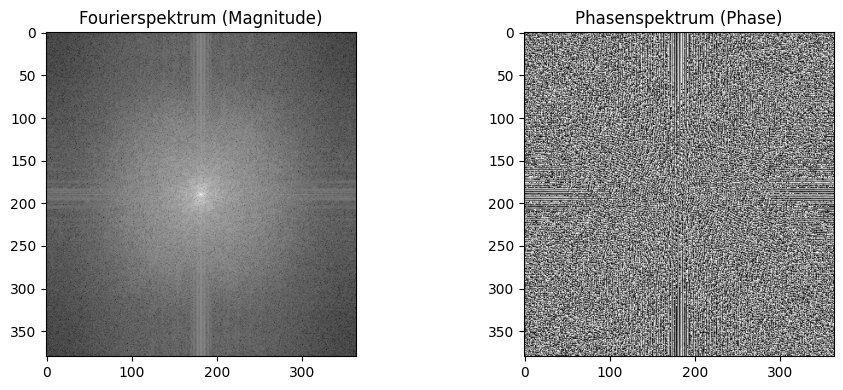

In [20]:
F = np.fft.fft2(img_original)   # Fouriertransformation
F = np.fft.fftshift(F)          # Zentrierung

magnitude = np.log(np.abs(F))
phase = np.angle(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(magnitude, cmap='gray'); axes[0].set_title('Fourierspektrum (Magnitude)')
axes[1].imshow(phase, cmap='gray');     axes[1].set_title('Phasenspektrum (Phase)')
plt.tight_layout()
plt.show()

## 3.2

In [21]:
rows, cols = F.shape
y_center, x_center = rows // 2, cols // 2
Y, X = np.indices(F.shape)
mask = np.sqrt((X - x_center)**2 + (Y - y_center)**2) <= 18

F_lp = F * mask

## 3.3

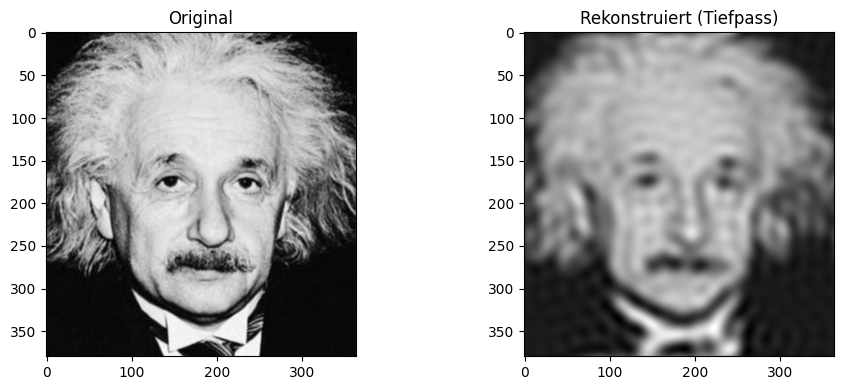

In [22]:
F_lp_shifted = np.fft.ifftshift(F_lp)               # Zentrierung rückgängig machen
img_reconstructed = np.fft.ifft2(F_lp_shifted)      # Inverse Fouriertransformation
img_reconstructed = np.real(img_reconstructed)      # Nur Realteil

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_original, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(img_reconstructed, cmap='gray'); axes[1].set_title('Rekonstruiert (Tiefpass)')
plt.tight_layout()
plt.show()

# Erkennbare Effekte:
# 1. Weichzeichnung (Blur): Durch das Entfernen hoher Frequenzen erscheint das Bild unscharf.
# 2. Ringing-Artefakte (Gibbs-Phänomen): An starken Kanten entstehen wellenartige Überschwingungen,
#    da der abrupte Schnitt im Frequenzbereich einer Faltung mit einer sinc-Funktion entspricht.


## 3.4

In [23]:
def gauss2d(x, y, mx, my, s):
    return 1. / (2. * np.pi * s * s) * np.exp(-((x - mx)**2. / (2. * s**2.) + (y - my)**2. / (2. * s**2.)))

# Gaußfilter zentriert auf Mittelpunkt des Fourierspektrums erstellen
rows, cols = F.shape
y_center, x_center = rows // 2, cols // 2
Y, X = np.indices(F.shape)
gauss_filter = gauss2d(X, Y, x_center, y_center, s=10)

# Elementweise Multiplikation im Frequenzraum
F_gauss = F * gauss_filter


## 3.5

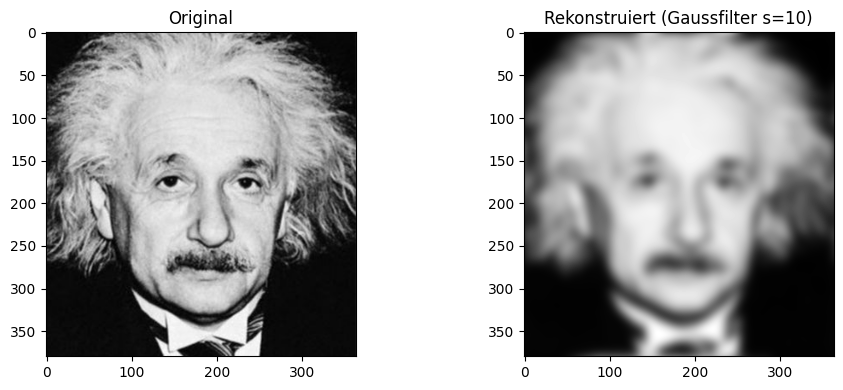

In [24]:
F_gauss_shifted = np.fft.ifftshift(F_gauss)         # Zentrierung rückgängig machen
img_reconstructed_2 = np.fft.ifft2(F_gauss_shifted)   # Inverse Fouriertransformation
img_reconstructed_2 = np.real(img_reconstructed_2)      # Nur Realteil

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_original, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(img_reconstructed_2, cmap='gray'); axes[1].set_title('Rekonstruiert (Gaussfilter s=10)')
plt.tight_layout()
plt.show()